## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [16]:
import sys
from pathlib import Path

import tensorflow as tf

PROJECT_DIR = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "common" / "ffnn_challenge_utils.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR / "common"))

from ffnn_challenge_utils import (
    CATEGORIES,
    DATASET_DIR,
    GenericImage,
    GenericObject,
    TEST_IMAGES_DIR,
    TRAIN_ANNOTATIONS_PATH,
    build_training_annotations,
    draw_confusion_matrix,
    image_generator as generator_images,
    load_annotations,
    load_geoimage,
)

print(tf.config.list_physical_devices('GPU'))

EXPERIMENT_DIR = PROJECT_DIR / "experiments" / "fnn_challenge" / "experiment_01"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
categories = CATEGORIES

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# GenericObject and GenericImage are provided by ffnn_challenge_utils.

In [3]:
categories = CATEGORIES

In [4]:
# load_geoimage is provided by ffnn_challenge_utils.

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [5]:
import json

json_data = load_annotations(TRAIN_ANNOTATIONS_PATH)

In [6]:
counts = dict.fromkeys(categories.values(), 0)
anns = build_training_annotations(json_data)
for ann in anns:
    for obj in ann.objects:
        counts[obj.category] += 1
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [7]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 16871
Number of validation images: 1875


In [8]:
# Load architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten

print('Load model')
model = Sequential()
model.add(Flatten(input_shape=(224, 224, 3)))
model.add(Activation('relu'))
model.add(Dense(len(categories)))
model.add(Activation('softmax'))
model.summary()

Load model
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 150528)            0         
                                                                 
 activation (Activation)     (None, 150528)            0         
                                                                 
 dense (Dense)               (None, 13)                1956877   
                                                                 
 activation_1 (Activation)   (None, 13)                0         
                                                                 
Total params: 1956877 (7.46 MB)
Trainable params: 1956877 (7.46 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-09-30 21:17:28.966586: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-30 21:17:28.966662: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-30 21:17:28.966697: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-30 21:17:29.123881: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-30 21:17:29.123948: I external/local_xla/xla/stream_executor

In [9]:
from tensorflow.keras.optimizers import Adam

# Learning rate is changed to 0.001
opt = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=40, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [11]:
# generator_images is provided by ffnn_challenge_utils.

In [12]:
# Generate the list of objects from annotations
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]
# Generators
batch_size = 16
train_generator = generator_images(objs_train, batch_size, do_shuffle=True)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)

In [13]:
import math
import numpy as np

print('Training model')
epochs = 20
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)
h = model.fit(train_generator, steps_per_epoch=train_steps, validation_data=valid_generator, validation_steps=valid_steps, epochs=epochs, callbacks=callbacks, verbose=1)
# Best validation model
best_idx = int(np.argmax(h.history['val_accuracy']))
best_value = np.max(h.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

Training model
Epoch 1/20


2026-09-30 21:17:33.737777: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-30 21:17:34.186671: I external/local_xla/xla/service/service.cc:168] XLA service 0x7e5c817e7dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-30 21:17:34.186710: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-09-30 21:17:34.204201: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-30 21:17:34.234560: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1790795854.329620   64499 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1053/1055 [============================>.] - ETA: 0s - loss: 3793.8594 - accuracy: 0.2601
Epoch 1: val_accuracy improved from -inf to 0.24533, saving model to model.keras
1055/1055 [==============================] - 43s 40ms/step - loss: 3795.0942 - accuracy: 0.2600 - val_loss: 4028.3264 - val_accuracy: 0.2453 - lr: 0.0010
Epoch 2/20
1053/1055 [============================>.] - ETA: 0s - loss: 3393.0029 - accuracy: 0.3027
Epoch 2: val_accuracy improved from 0.24533 to 0.34880, saving model to model.keras
1055/1055 [==============================] - 28s 27ms/step - loss: 3392.8069 - accuracy: 0.3029 - val_loss: 3581.9785 - val_accuracy: 0.3488 - lr: 0.0010
Epoch 3/20
1054/1055 [============================>.] - ETA: 0s - loss: 3460.3167 - accuracy: 0.3108
Epoch 3: val_accuracy did not improve from 0.34880
1055/1055 [==============================] - 28s 26ms/step - loss: 3460.3538 - accuracy: 0.3108 - val_loss: 3947.4749 - val_accuracy: 0.2875 - lr: 0.0010
Epoch 4/20
1055/1055 [========

#### Validation
Compute validation metrics.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# draw_confusion_matrix is provided by ffnn_challenge_utils.

In [17]:
import numpy as np

model.load_weights(str(EXPERIMENT_DIR / "model.keras"))
y_true, y_pred = [], []
for ann in anns_valid:
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        y_true.append(obj_pred.category)
        y_pred.append(pred_category)

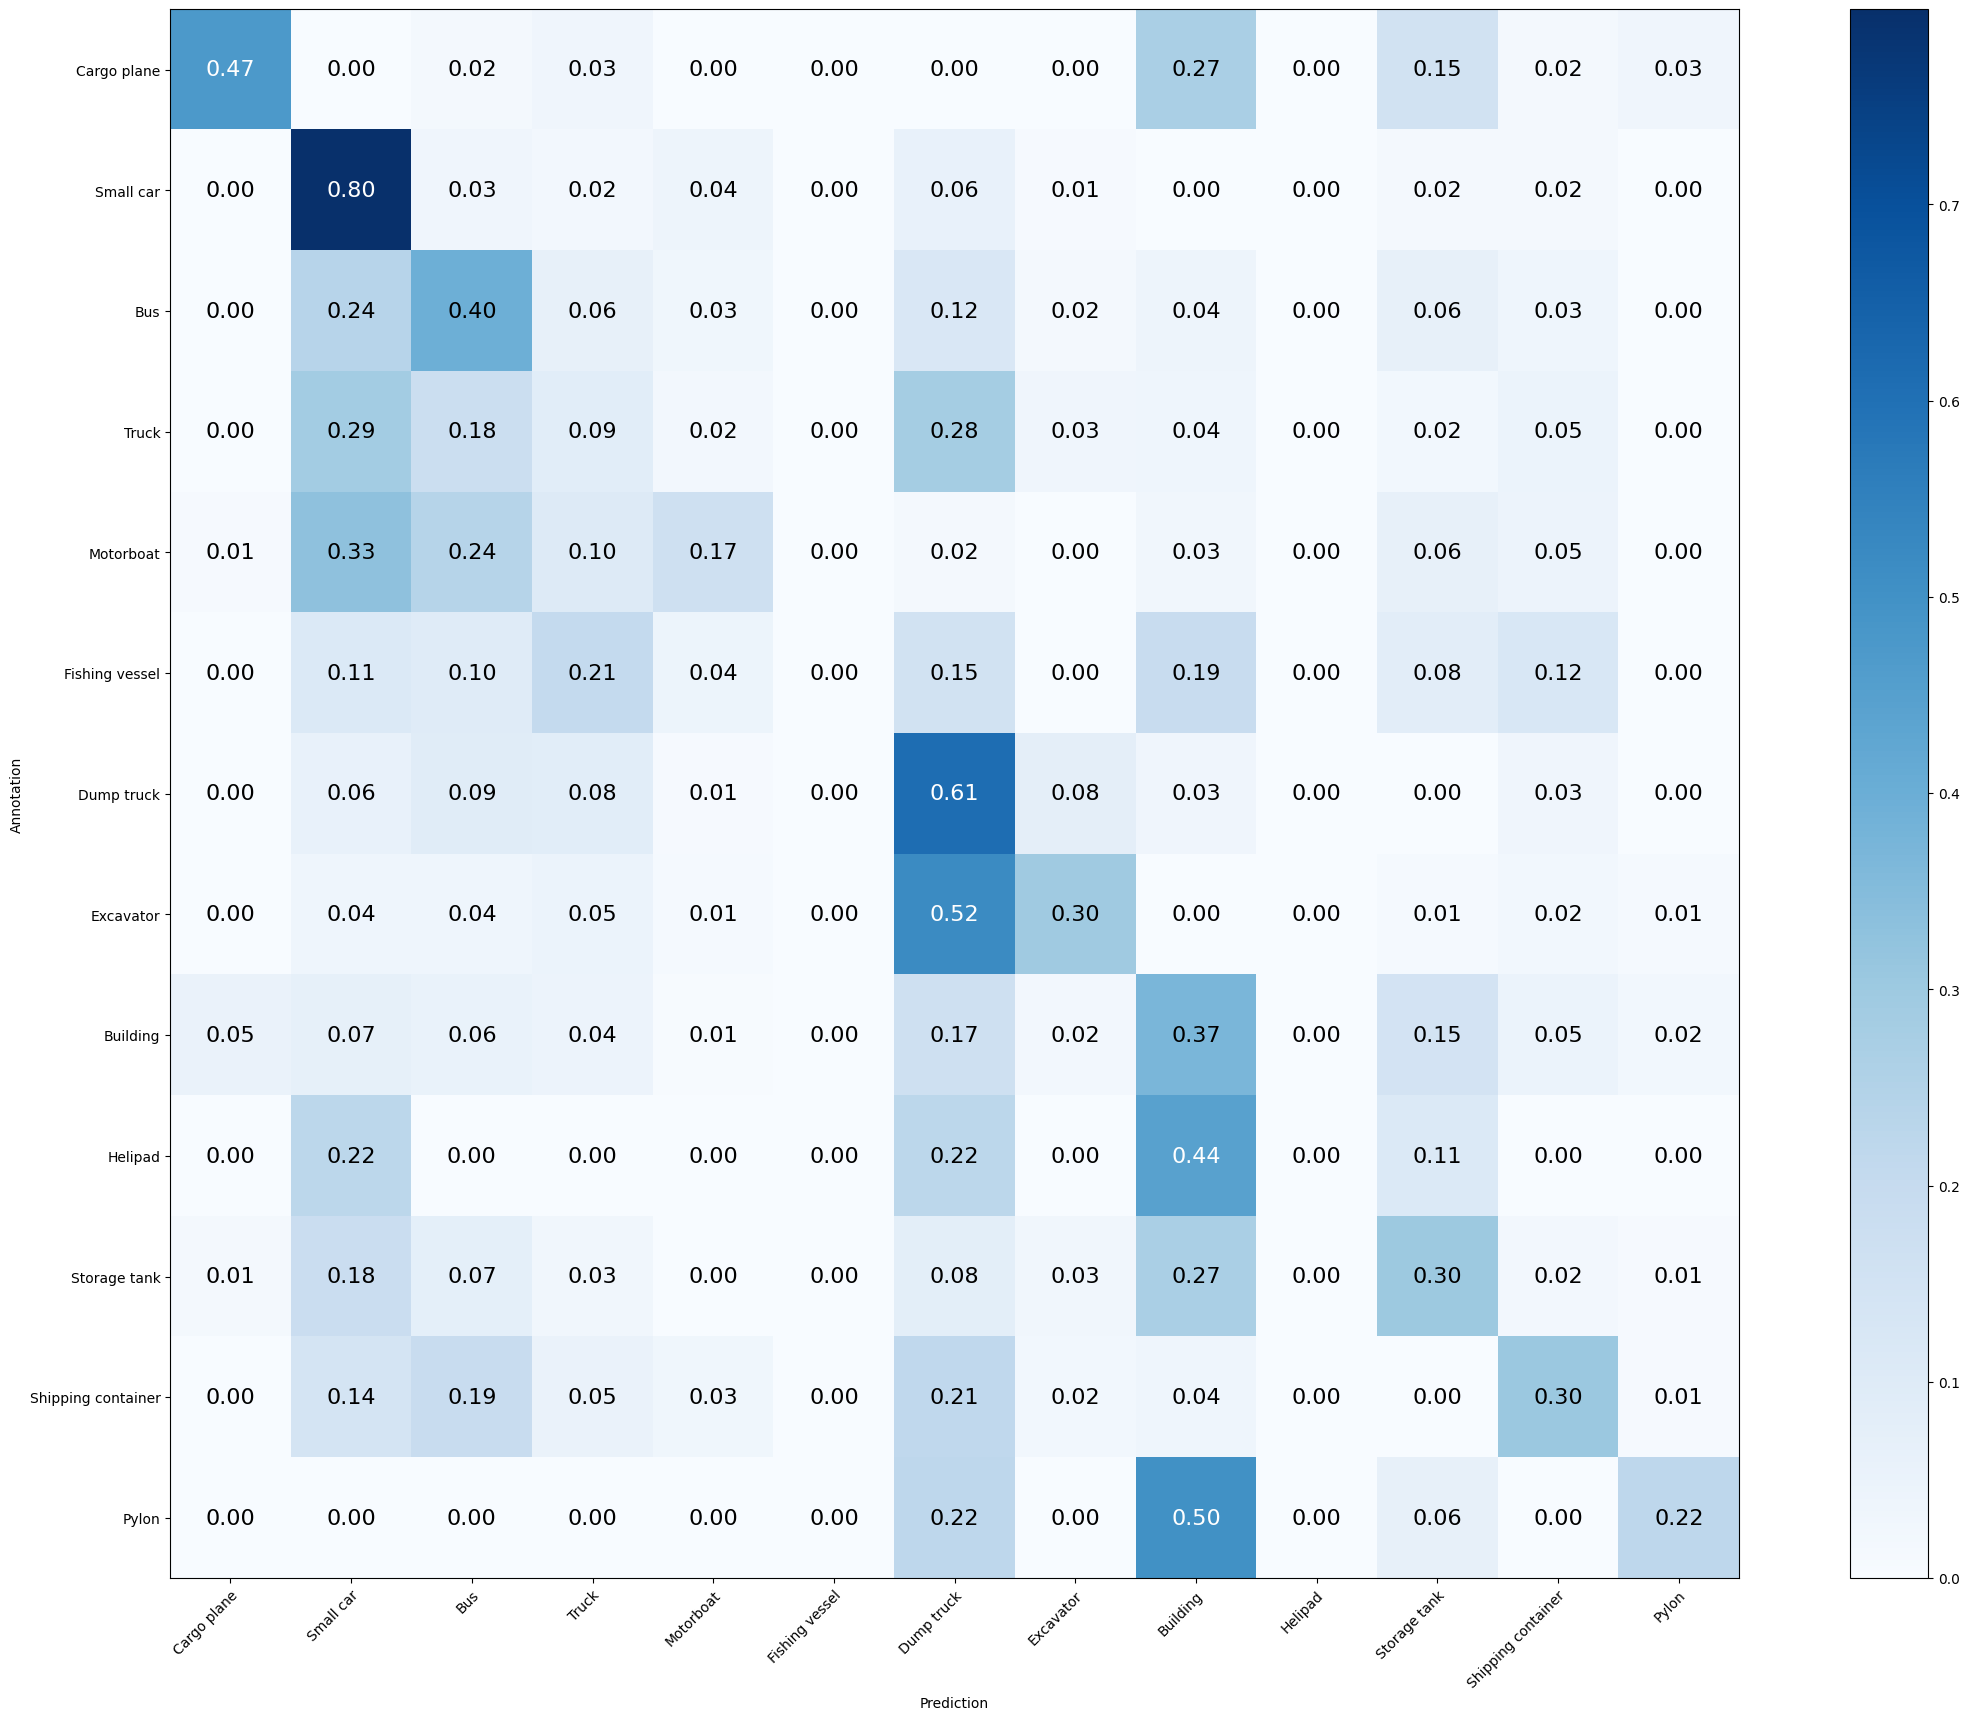

In [18]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [19]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 38.560%
Mean Recall: 30.950%
Mean Precision: 31.433%
> Cargo plane: Recall: 47.458% Precision: 56.000% Specificity: 98.789% Dice: 51.376%
> Small car: Recall: 79.939% Precision: 52.600% Specificity: 84.670% Dice: 63.450%
> Bus: Recall: 39.655% Precision: 30.263% Specificity: 90.653% Dice: 34.328%
> Truck: Recall: 8.714% Precision: 19.444% Specificity: 94.676% Dice: 12.034%
> Motorboat: Recall: 16.514% Precision: 34.615% Specificity: 98.075% Dice: 22.360%
> Fishing vessel: Recall: 0.000% Precision: 0.000% Specificity: 100.000% Dice: 0.000%
> Dump truck: Recall: 61.017% Precision: 20.870% Specificity: 84.462% Dice: 31.102%
> Excavator: Recall: 29.630% Precision: 39.344% Specificity: 97.938% Dice: 33.803%
> Building: Recall: 36.915% Precision: 52.756% Specificity: 92.063% Dice: 43.436%
> Helipad: Recall: 0.000% Precision: 0.000% Specificity: 99.946% Dice: 0.000%
> Storage tank: Recall: 30.263% Precision: 31.081% Specificity: 94.080% Dice: 30.667%
> Shipping container: Recal

#### Testing
Try to improve the results provided in the competition.

In [20]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk(TEST_IMAGES_DIR):
    for filename in filenames:
        relative_directory = Path(dirpath).relative_to(DATASET_DIR).as_posix()
        image = GenericImage(relative_directory + '/' + filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = Path(dirpath).name
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [21]:
import numpy as np

model.load_weights(str(EXPERIMENT_DIR / "model.keras"))
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

In [22]:
with open(EXPERIMENT_DIR / "prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)